# Examen Data Science Mei 2026

| | |
| :--- | :--- |
| **Student Voornaam:** | Seppe |
| **Student Familienaam:** | Van Opstal |
| **Studentennummer:** | 202404851 |
| **Datum & uur:** | Vrijdag 29 mei 2026, 12:30 |
| **Klasgroep:** | 2c1 |
| **IOEM-student:** | NEE |

Voeg Python code of het antwoord toe in de voorziene codecellen. Je kan codecellen toevoegen voor het uitwerken van de vragen.

**VERGEET DE SCHERMOPNAME NIET!!**

Dit deel van het examen staat in totaal op 30 punten.

In [2]:
# Importing the necessary packages
# Voeg zelf indien nodig nog extra packages toe
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing



## Vraag 1 [3 pt]

Stel dat de prijs voor een standaardkamer in een 4-sterren hotel in Spanje tijdens hoogseizoen normaal verdeeld is met mu = 160 en sigma = 30.

1. [1 pt] Wat is de kans dat je tussen 140 en 180 EUR per nacht betaalt?
2. [1 pt] Wat is de kans dat je voor een verblijf van (8 dagen /) 7 nachten minder dan 1000 EUR betaalt?
3. [1 pt] Vanaf welke prijs per nacht behoort de kamer tot de 10% duurste kamers?


In [3]:
# 1. Wat is de kans dat je tussen 140 en 180 EUR per nacht betaalt?
mu = 160
sigma = 30

print(stats.norm.cdf(180, loc=mu, scale=sigma) - stats.norm.cdf(140, loc=mu, scale=sigma))

0.4950149249061542


In [4]:
# 2. Wat is de kans dat je voor een verblijf van (8 dagen /) 7 nachten minder dan 1000 EUR betaalt?
n = 7
mu = 160
sigma = 30

mu7 = 160*7
sigma7 = np.sqrt(n) * sigma
print(stats.norm.cdf(1000, loc=mu7, scale=sigma7))



0.0652850090578681


In [5]:
# 3. Vanaf welke prijs per nacht behoort de kamer tot de 10% duurste kamers?


print(stats.norm.ppf(0.9, loc=mu, scale=sigma))

198.44654696633802


## Vraag 2 [5 pt]

In het onderstaande dataframe staat het aantal reizen (x 1000) per jaar gemaakt door Belgen naar de 3 binnenlandse bestemmingen: de kust, de ardennen en kunststeden. [Bron: StatBel]   

1. [1 pt] Maak de onderstaande plot  

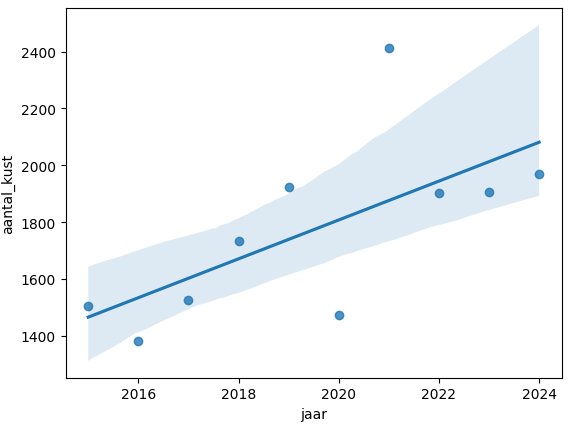


2. [1 pt] Wat is te verwachten waarde voor het aantal kustvakanties in 2026?
3. [1 pt] Bereken en geef de waarde van de correlatiecoëfficiënt voor de kustvakanties.
4. [1 pt] Geef de betekenis van de waarde van deze correlatiecoëfficiënt.
5. [1 pt] Een snelle blik op de cijfers van de Ardennen toont dat ook het aantal vakanties in de Ardennen toeneemt. Is het groeiritme van de vakanties aan de Kust hoger, lager of gelijk aan het groeiritme van de vakanties in de Ardennen



In [2]:
df_vakanties_binnenland = pd.DataFrame({
    'jaar': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'aantal_kust': [1507, 1383, 1528, 1733, 1923, 1475, 2411, 1902, 1905, 1970],
    'aantal_ardennen': [972, 1039, 1162, 1377, 1469, 1519, 2013, 1646, 1695, 1628],
    'aantal_kuststeden': [523, 410, 454, 674, 654, 431, 842, 821, 849, 736]})
df_vakanties_binnenland.head()

,jaar,aantal_kust,aantal_ardennen,aantal_kuststeden
0,2015,1507,972,523
1,2016,1383,1039,410
2,2017,1528,1162,454
3,2018,1733,1377,674
4,2019,1923,1469,654


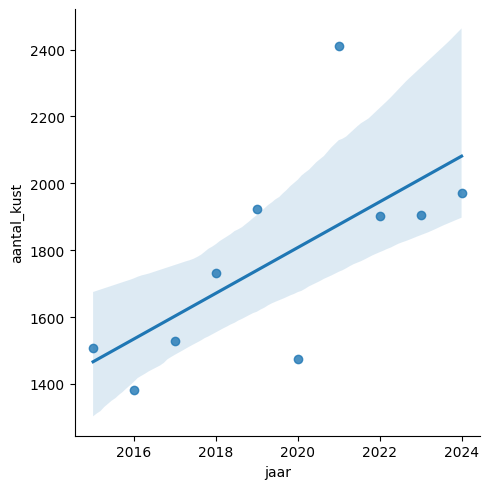

In [3]:
# 1. Maak de plot
sns.lmplot(data=df_vakanties_binnenland, x='jaar', y='aantal_kust')


In [13]:
# 2. Wat is te verwachten waarde voor het aantal kustvakanties in 2026?
from sklearn.linear_model import LinearRegression

xKust = df_vakanties_binnenland[['jaar']]
yKust = df_vakanties_binnenland['aantal_kust']

modelKust = LinearRegression().fit(xKust,yKust)

predictKust = modelKust.predict([[2026]])[0]
print(f"Te verwachten aantal kustvakanties in 2026: {predictKust:.4f}")


Te verwachten aantal kustvakanties in 2026: 2217.9455


/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# 3. Bereken en geef de waarde van de correlatiecoëfficiënt voor de kustvakanties.
corKust = np.corrcoef(df_vakanties_binnenland['jaar'], df_vakanties_binnenland['aantal_kust'])[0][1]
print(f"R ≈ {corKust:.4f}")

R ≈ 0.6634


In [8]:
# 4. Geef de betekenis van de waarde van deze correlatiecoëfficiënt.
'''
Antwoord: De correlatie is 0.6634, dat wil zeggen dat de waarnemingen niet super dicht tegen de regressie lijn liggen maar ook niet super ver ervan af. 
'''

'\nAntwoord: De correlatie is 0.6634, dat wil zeggen dat de waarnemingen niet super dicht tegen de regressie lijn liggen maar ook niet super ver ervan af. \n'

In [15]:
# 5. Een snelle blik op de cijfers van de Ardennen toont dat ook het aantal vakanties in de Ardennen toeneemt.
# Is het groeiritme van de vakanties aan de Kust hoger, lager of gelijk aan het groeiritme van de vakanties in de Ardennen
corrArdennen = np.corrcoef(df_vakanties_binnenland['jaar'], df_vakanties_binnenland['aantal_ardennen'])[0][1]
print(f"R ≈ {corrArdennen:.4f}")
corKust = np.corrcoef(df_vakanties_binnenland['jaar'], df_vakanties_binnenland['aantal_kust'])[0][1]
print(f"R ≈ {corKust:.4f}")

R ≈ 0.8455
R ≈ 0.6634


## Vraag 3 [7.5 pt]

De dataframe bevat het aantal vakantiereizen (x 1000) per kwartaal voor alle Belgen. (Bron: StatBel)

1. [0.5 pt] Maak van de kolom 'datum' echte datums. Stel 'datum' in als index.
2. [1 pt] Maak de onderstaande plot.  

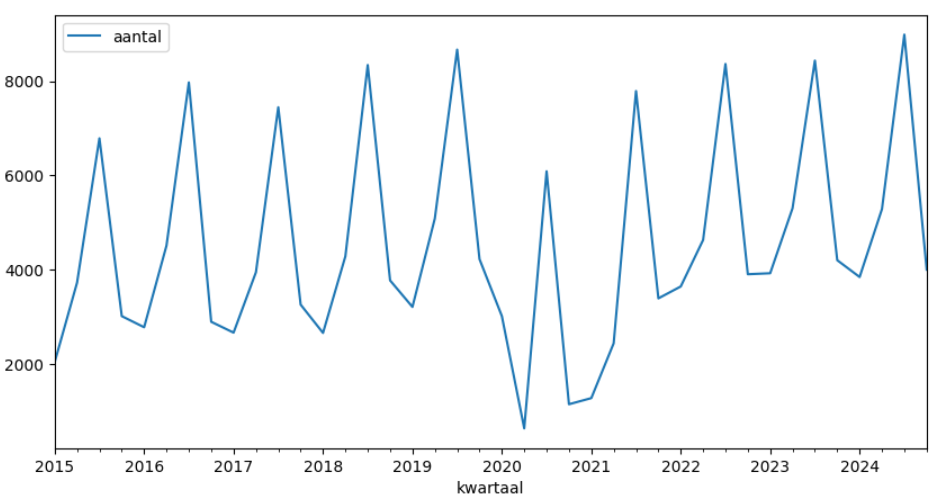


3. [1 pt] Splits de data op in trainingsdata (2015 tot en met 2023) en testdata (2024)
4. [1 pt] Train een geschikt model op de trainingsdata.
5. [1 pt] Maak voorspellingen voor 2024 en bepaal hoe goed het model presteert op de testdata.
6. [1 pt] Maak een plot van de trainingsdata, de testdata en de voorspelde data.
7. [1 pt] In hoeveel kwartalen waren er meer dan 5000 reizen?
8. [1 pt] In 2020 en 2021 is er een duidelijke coronadip. Maak een schatting van het aantal reizen in het eerste kwartaal van 2020 indien er geen Corona was geweest op basis van de data tot en met eind 2019.

In [37]:
df_vakanties = pd.DataFrame({
    'kwartaal': ['2015-03-31', '2015-06-30', '2015-09-30', '2015-12-31', '2016-03-31', '2016-06-30', '2016-09-30', '2016-12-31', '2017-03-31', '2017-06-30', '2017-09-30', '2017-12-31', '2018-03-31', '2018-06-30', '2018-09-30', '2018-12-31', '2019-03-31', '2019-06-30', '2019-09-30', '2019-12-31', '2020-03-31', '2020-06-30', '2020-09-30', '2020-12-31', '2021-03-31', '2021-06-30', '2021-09-30', '2021-12-31', '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31', '2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31', '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31'],
    'aantal':  [2039, 3725, 6786, 3014, 2778, 4511, 7972, 2894, 2664, 3945, 7445, 3258, 2658, 4282, 8341, 3772, 3209, 5083, 8668, 4222, 3014, 633, 6087, 1145, 1275, 2438, 7789, 3391, 3643, 4630, 8363, 3903, 3924, 5303, 8435, 4200, 3844, 5286, 8986, 4001]
})

df_vakanties.head()
df_vakanties.info()


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   kwartaal  40 non-null     str  
 1   aantal    40 non-null     int64
dtypes: int64(1), str(1)
memory usage: 772.0 bytes


In [38]:
# 1. Maak van de kolom 'datum' echte datums. Stel 'datum' in als index.
df_vakanties['kwartaal'] = pd.to_datetime(df_vakanties['kwartaal'])
df_vakanties.set_index('kwartaal', inplace=True)
df_vakanties.head()

,aantal
kwartaal,
2015-03-31,2039
2015-06-30,3725
2015-09-30,6786
2015-12-31,3014
2016-03-31,2778


<Axes: xlabel='kwartaal'>

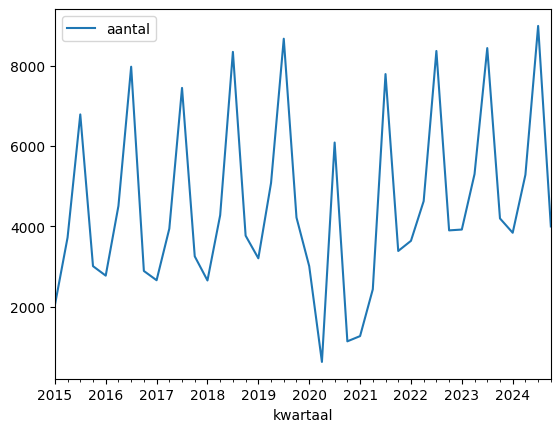

In [39]:
# 2. Maak de onderstaande plot.
df_vakanties.plot()


In [40]:
# 3. Splits de data op in trainingsdata (2015 tot en met 2023) en testdata (2024)
train = df_vakanties.loc['2015-03-31':'2023-12-31']
test = df_vakanties.loc['2024-03-31':'2024-12-01']


In [44]:
# 4. Train een geschikt model op de trainingsdata.
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelVakanties = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=3)
fitVakanties = modelVakanties.fit()



/home/seppevo/repo/dsai-labs/.venv/lib64/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


In [45]:
# 5. Maak voorspellingen voor 2024 en bepaal hoe goed het model presteert op de testdata.

forecastVakanties2024 = fitVakanties.forecast(2024)
print(forecastVakanties2024)

2024-03-31     4745.225612
2024-06-30     4914.300073
2024-09-30     5104.690221
2024-12-31     4820.996074
2025-03-31     4990.070535
                  ...     
2528-12-31    55738.746535
2529-03-31    55907.820996
2529-06-30    56098.211144
2529-09-30    55814.516997
2529-12-31    55983.591458
Freq: QE-DEC, Length: 2024, dtype: float64


<Axes: xlabel='kwartaal'>

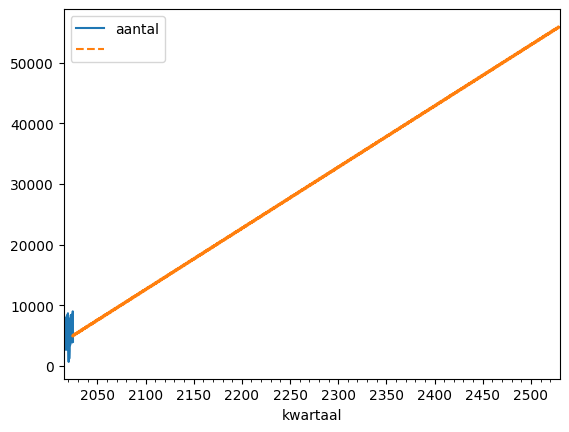

In [46]:
# 6.  Maak een plot van de trainingsdata, de testdata en de voorspelde data.
df_vakanties['aantal'].plot(legend=True)
forecastVakanties2024.plot(legend=True,linestyle='--')

In [47]:
# 7. In hoeveel kwartalen waren er meer dan 5000 reizen?

kwartalen = (df_vakanties['aantal']> 5000).sum()
print(f"Maanden met meer dan 5000 reizen: {kwartalen}")

Maanden met meer dan 5000 reizen: 13


In [ ]:
# 8. In 2020 en 2021 is er een duidelijke coronadip. Maak een schatting van het aantal reizen in het eerste kwartaal van 2020 indien er geen Corona was geweest op basis van de data tot en met eind 2019.


## Vraag 4 [6 pt]
De onderstaande dataframe geeft het aantal reizen naar Nederland en naar Spanje per kwartaal. Zijn er signficant meer reizen naar Nederland dan naar Spanje?

1. [1 pt] Maak een plot  
2. [1 pt] Welke statistische test zal je gebruiken om dit te bepalen?
3. [0.5 pt] Formuleer de nulhypothese en de alternatieve hypothese.
4. [1 pt] Bereken de p-waarde.
5. [0.5 pt] Trek een conclusie op basis van deze waarde en beantwoord de onderzoeksvraag.
6. Het antwoord strookt niet helemaal met de verwachtingen.
* 6.1 [1 pt] Maak op basis van het dataframe 2 lists: 1 list met de waarden voor kwartaal 3 (= zomermaanden) van Nederland en 1 list voor Spanje
* 6.2 [1 pt] Formuleer de nulhypothese en de alternatieve hypothese. Bereken opnieuw de p-waarde. Trek een conclusie.

In [48]:
df_buitenland = pd.DataFrame({
    'kwartaal': ['2015-03-31', '2015-06-30', '2015-09-30', '2015-12-31', '2016-03-31', '2016-06-30', '2016-09-30', '2016-12-31', '2017-03-31', '2017-06-30', '2017-09-30', '2017-12-31', '2018-03-31', '2018-06-30', '2018-09-30', '2018-12-31', '2019-03-31', '2019-06-30', '2019-09-30', '2019-12-31', '2020-03-31', '2020-06-30', '2020-09-30', '2020-12-31', '2021-03-31', '2021-06-30', '2021-09-30', '2021-12-31', '2022-03-31', '2022-06-30', '2022-09-30', '2022-12-31', '2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31', '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31'],
    'aantal_nederland': [ 185, 276, 441, 267, 353, 526, 593, 477, 296, 567, 529, 331, 232, 388, 585, 388, 391, 550, 666, 504, 238, 106, 393, 58, 22, 109, 409, 303, 251, 421, 639, 395, 454, 646, 646, 367, 318, 509, 592, 428],
    'aantal_spanje':[147, 392, 601, 261, 211, 543, 806, 369, 278, 350, 745, 382, 254, 452, 707, 384, 250, 492, 682, 390, 219, 4, 266, 61, 35, 129, 519, 281, 299, 537, 727, 367, 225, 518, 795, 436, 296, 572, 866, 315]
 })

df_buitenland.head()


,kwartaal,aantal_nederland,aantal_spanje
0,2015-03-31,185,147
1,2015-06-30,276,392
2,2015-09-30,441,601
3,2015-12-31,267,261
4,2016-03-31,353,211


In [54]:
df_buitenland.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   kwartaal          40 non-null     str  
 1   aantal_nederland  40 non-null     int64
 2   aantal_spanje     40 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.1 KB


<Axes: >

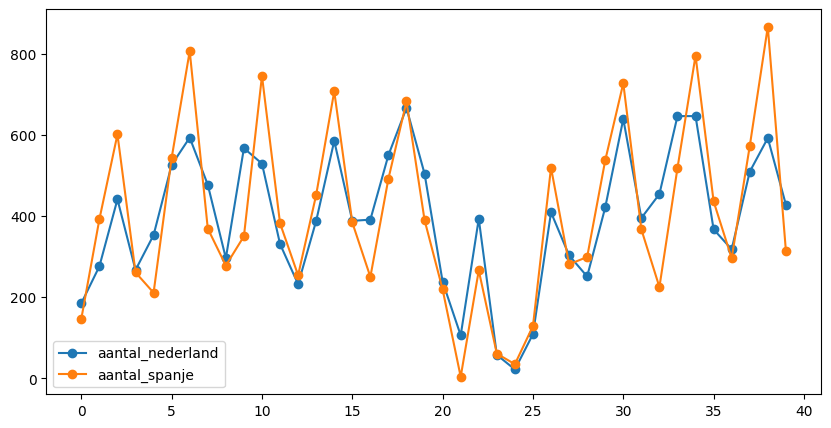

In [64]:
df_buitenland.plot(kind='line', marker='o', figsize=(10, 5))


In [51]:
# 2. Welke statistische test zal je gebruiken om dit te bepalen
'''
Antwoord: De independent T-test, de twee groepen zijn onafhankelijk van elkaar, de deelnemers in de ene groep hebben geen relatie met de deelnemers in de andere groep

'''


'\nAntwoord: De independent T-test, de twee groepen zijn onafhankelijk van elkaar, de deelnemers in de ene groep hebben geen relatie met de deelnemers in de andere groep\n\n'

In [67]:
# 3. Formuleer de nulhypothese en de alternatieve hypothese.

'''
Antwoord: H0: Er zijn niet meer reizen naar Nederland dan naar Spanje, ze zijn gelijk
          H1: Er zijn meer reizen naar Nederland dan naar Spanje

'''

'\nAntwoord: H0: Er zijn niet meer reizen naar Nederland dan naar Spanje, ze zijn gelijk\n          H1: Er zijn meer reizen naar Nederland dan naar Spanje\n\n'

In [66]:
# 4. Bereken de p-waarde.

tVakantie, pVakantie = stats.ttest_ind(df_buitenland['aantal_nederland'], df_buitenland['aantal_spanje'], alternative='greater')
print(f"T-statistiek: {tVakantie:.3f}")
print(f"P-waarde: {pVakantie:.4f}")

T-statistiek: -0.180
P-waarde: 0.5712


In [ ]:
# 5. Trek een conclusie op basis van deze waarde en beantwoord de onderzoeksvraag.
'''
Antwoord: P is 0.5712 wat meer is als 0.05 dus we verwerpen de nulhypothese niet. Er is niet genoeg bewijs dat er meer reizen zijn naar Nederland dan naar Spanje

'''

In [ ]:
# 6.1 Maak op basis van het dataframe 2 lists: 1 list met de waarden voor kwartaal 3 (= zomermaanden) van Nederland en 1 list voor Spanje
# Als dit niet lukt, kan je de volgende lijsten gebruiken
# aantal_nederland_q3 = [441, 593, 529, 585, 666, 393, 409, 639, 646, 592]
# aantal_spanje_q3 = [601, 806, 745, 707, 682, 266, 519, 727, 795, 866]


In [ ]:
# 6.2 Bereken opnieuw de p-waarde + trek een conclusie

'''
Antwoord:

'''

## Vraag 5 [4.5 pt]

Een overnachting in een tweepersoonskamer aan de Belgische kust deze zomer kost gemiddeld 254 EUR met een standaardafwijking van 114 EUR.

We vonden een brochure met daarin de volgende prijzen voor een overnachting aan de Belgische kust deze zomer. Suggereren de hieronder gegevens prijzen dat de werkelijke prijzen lager zijn 254 EUR? Voer een test uit met 5% significance level om deze vraag te beantwoorden.

1. [0.5 pt] De standaardafwijking is 114 EUR. Wat is de concrete betekenis hiervan toegepast op hotels aan de Belgische kust?
2. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!  
3. [0.5 pt] Formuleer de nulhypothese en de alternatieve hypothese  
4. [1 pt] Maak de berekeningen die horen bij deze toets.  
5. [0.5 pt] Geef de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde.  
6. [0.5 pt] Geef de p-waarde  
7. [0.5 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.  


In [68]:
prijzen = [109, 115, 122, 130, 138, 245, 150, 165, 175, 118, 141, 155, 169, 260, 135, 192, 208, 124, 137, 146, 159, 275, 140, 183, 198, 128, 152, 166, 179, 295, 144, 201, 219, 132, 148, 157, 185, 309, 154, 210, 229, 139, 161, 174, 192, 330, 158, 221, 239, 145, 169, 186, 199, 345, 162, 234, 249, 152, 176, 194, 208, 359, 169, 241, 259, 158, 184, 203, 216, 375, 175, 253, 269, 165, 191, 211, 225, 389, 181, 261, 279, 171, 199, 218, 234, 405, 189, 275, 289, 178, 208, 227, 243, 419, 196, 288, 299, 186, 215, 235]

In [93]:
# 1. De standaardafwijking is 114 EUR. Wat is de concrete betekenis hiervan toegepast op hotels aan de Belgische kust?

'''
Antwoord: Van 25% tot 75% is er 114 eur vershil en daartussen zit de mediaan van 254EUR

'''

'\nAntwoord: Van 25% tot 75% is er 114 eur vershil en daartussen zit de mediaan van 254EUR\n\n'

In [ ]:
# 2. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
'''
Antwoord:


'''

In [98]:
# 3. Formuleer de nulhypothese en de alternatieve hypothese
'''
Antwoord: H0: de prijzen zijn lager als 254 aan de hand van deze sample. H1: Er is voldoende bewijs om te zeggen dat de prijzen niet lager zijn als 254


'''

'\nAntwoord: H0: de prijzen zijn lager als 254 aan de hand van deze sample. H1: Er is voldoende bewijs om te zeggen dat de prijzen niet lager zijn als 254\n\n\n'

In [90]:
# 4. Maak de berekeningen die horen bij deze toets.
mu = 254
sigma = 114
n = len(prijzen)
alpha = 0.05
samplemean = np.mean(prijzen)
samplestd = np.std(prijzen,ddof=1)
stderr = samplestd / np.sqrt(n)
t = (samplemean - mu) / stddErr
p = 1 - stats.t.cdf(t, df=n-1)
print(p)


0.9999748076471058


In [ ]:
# 5. Geef de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde.
'''
Antwoord:

'''


In [ ]:
# 6. Geef de p-waarde
'''
Antwoord: De p waarde is 0.9999.

'''

In [91]:
# 7. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.
'''
Antwoord:De p waarde is groter als sigma, wat wilt zeggen dat we nul hypothese niet verwerpen.


'''

'\nAntwoord:De p waarde is groter als sigma, wat wilt zeggen dat we nul hypothese niet verwerpen.\n\n\n'

## Vraag 6 [4 pt]
In de dataframe hieronder staan de cijfers (x1000) van het aantal reizen gemaakt door inwoners van de drie gewesten van België voor 2024. Gingen inwoners van Brussel, Vlaanderen en Wallonië naar verhouding even vaak op reis over het gehele jaar 2024 als je weet dat het aantal inwoners van deze gewesten respectievelijk 1250, 6822, en 3692 (x1000) is?

1. [0.5 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
2. [0.5 pt] Formuleer de nulhypothese en de alternatieve hypothese
3. [1.5 pt] Maak de berekeningen die horen bij deze toets.
4. [0.5 pt] Geef de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde.
5. [0.5 pt] Geef de p-waarde
6. [0.5 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

In [99]:
df_reizen = pd.DataFrame(
    index=['Q1_2024', 'Q2_2024', 'Q3_2024', 'Q4_2024'],
    data={
        'Brussel':    [ 724,  788, 1145,  543],
        'Vlaanderen': [2402, 3455, 5930, 2713],
        'Wallonie':   [1089, 1531, 2203, 1020]})
df_reizen.head()

,Brussel,Vlaanderen,Wallonie
Q1_2024,724,2402,1089
Q2_2024,788,3455,1531
Q3_2024,1145,5930,2203
Q4_2024,543,2713,1020


In [101]:
# 1. Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
'''
Antwoord: de chi2_contingency


'''

'\nAntwoord: de chi2_contingency\n\n\n'

In [ ]:
# 2.  Formuleer de nulhypothese en de alternatieve hypothese
'''
Antwoord: H0 Ze gaan even vaak op reis in 2024. H1 er is bewijs om te zeggen dat een gewest vaker op reis ging

'''

In [ ]:
# 3. Maak de berekeningen die horen bij deze toets.
observed = pd.crosstab(df_reizen.Brussel, df_reizen.Vlaanderen, df_reizen.Wallonie)
chi2, p, df, expected = stats.chi2_contingency(observed)
print("Chi-squared       : %.4f" % chi2)
print("Degrees of freedom: %d" % df)
print("P-value           : %.4f" % p)

In [ ]:
# 4. Geef de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde.

'''
Antwoord:


'''

In [ ]:
# 5. Geef de p-waarde
'''
Antwoord:

'''

In [ ]:
# 6. Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.
'''
Antwoord:

'''